# Python FDFK Scaling vs Fortran Reference

This notebook compares **Python hybrid FD–FK** wall-clock scaling (Sherlock cluster runs in
`sherlock/results/`) against the Fortran logs parsed in `scaling_comparison.ipynb`.

**Baseline** (Fortran `test1_1`): 200 km × 50 km, Δx = Δz = 200 m, Δt = 0.01 s,
t_max = 40 s → nx = 1001, nz = 251, nt = 4001, FD order 16 (half-order 8), nPML = 20.

| Suite | Varies | Fixed |
|-------|--------|-------|
| **Thread scaling** | Numba/OpenMP threads 1, 2, 4, 8, 16, 32 | Baseline grid |
| **Spatial scaling** | Grid scale 1, 2, 4, 8, 16 (Fortran nx×nz pattern) | 8 threads |

Sherlock jobs were submitted via `sherlock/submit_all.sh`; each case writes a private JSON
under `sherlock/results/` (e.g. `python_t8.json`). This notebook merges those files with
`sherlock/merge_results.py` and plots against Fortran reference timings.

Optional: run new local benchmarks with `run_python_scaling.py` (see section below).

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXAMPLE_DIR = Path(".").resolve()
PROJECT_ROOT = EXAMPLE_DIR.parents[1]
SHERLOCK_DIR = EXAMPLE_DIR / "sherlock"
SHERLOCK_RESULTS_DIR = SHERLOCK_DIR / "results"
SHERLOCK_MERGED_PATH = EXAMPLE_DIR / "python_scaling_times_sherlock.json"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SHERLOCK_DIR) not in sys.path:
    sys.path.insert(0, str(SHERLOCK_DIR))

from merge_results import merge_results
from parse_scaling_times import discover_runs, format_summary_table
from run_python_scaling import (
    CACHE_PATH,
    SPATIAL_GRIDS,
    TMAX,
    format_python_table,
    missing_spatial_labels,
    missing_thread_labels,
    run_spatial_scaling,
    run_thread_scaling,
)

DATA_DIR = EXAMPLE_DIR / "FDFK_Scaling_Fortran"
print(f"Project root:       {PROJECT_ROOT}")
print(f"Sherlock results:   {SHERLOCK_RESULTS_DIR}")
print(f"Local cache:        {CACHE_PATH}")
print(f"Local CPU cores:    {os.cpu_count()}")

Project root:       /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python
Sherlock results:   /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/examples/2_Scaling_Comparison/sherlock/results
Local cache:        /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/examples/2_Scaling_Comparison/python_scaling_times.json
Local CPU cores:    12


## Run simulations (optional)

| Flag | Behavior |
|------|----------|
| `RUN_IF_MISSING = True` | Run only cases **not** already in `python_scaling_times.json` (default) |
| `RUN_SIMULATIONS = True` | Always enter the runner (still skips cached cases unless `FORCE_RERUN`) |
| `FORCE_RERUN = True` | Re-run every case, ignoring the cache |

Each thread count runs in a **fresh subprocess** so Numba picks up `NUMBA_NUM_THREADS`
before JIT compilation. Full suite (12 thread + 5 spatial cases at t_max = 40 s) typically
takes **1–2 hours** on a 12-core laptop.

In [2]:
RUN_IF_MISSING = False   # auto-run cases missing from python_scaling_times.json
RUN_SIMULATIONS = False  # set True to always invoke the runner
FORCE_RERUN = False      # ignore cache and re-run all cases when True
THREAD_COUNTS = [1, 2, 4, 8, 16, 32]  # matches sherlock/submit_all.sh
SPATIAL_SCALES = [1, 2, 4, 8, 16]
SPATIAL_THREADS = 8

missing_thread = missing_thread_labels(THREAD_COUNTS)
missing_spatial = missing_spatial_labels(SPATIAL_SCALES)
should_run = RUN_SIMULATIONS or (RUN_IF_MISSING and (missing_thread or missing_spatial))

if should_run:
    if missing_thread or missing_spatial:
        print("Missing from cache:")
        if missing_thread:
            print(f"  thread:  {', '.join(missing_thread)}")
        if missing_spatial:
            print(f"  spatial: {', '.join(missing_spatial)}")
    elif FORCE_RERUN:
        print("FORCE_RERUN=True — re-running all cases.")
    else:
        print("All requested cases already cached.")

    run_thread_scaling(
        threads=THREAD_COUNTS,
        skip_existing=not FORCE_RERUN,
        use_subprocess=True,
        verbose=True,
    )
    run_spatial_scaling(
        scales=SPATIAL_SCALES,
        n_threads=SPATIAL_THREADS,
        skip_existing=not FORCE_RERUN,
        use_subprocess=True,
        verbose=True,
    )
else:
    print(
        "Skipping simulations (cache complete; "
        "set RUN_IF_MISSING=True or RUN_SIMULATIONS=True to run)."
    )

Skipping simulations (cache complete; set RUN_IF_MISSING=True or RUN_SIMULATIONS=True to run).


## Load timing data

Sherlock per-job JSON files are merged on the fly; re-run this section after syncing new
`results/*.json` from the cluster.

In [3]:
if not SHERLOCK_RESULTS_DIR.is_dir():
    raise FileNotFoundError(
        f"Missing {SHERLOCK_RESULTS_DIR}. Sync Sherlock results or run merge_results.sh."
    )

sherlock_cache = merge_results(
    results_dir=SHERLOCK_RESULTS_DIR,
    output_path=SHERLOCK_MERGED_PATH,
)
py_runs = sherlock_cache.get("runs", [])
if not py_runs:
    raise RuntimeError(f"No runs found under {SHERLOCK_RESULTS_DIR}")

py_host = py_runs[0].get("host", "unknown")
py_thread = sorted([r for r in py_runs if r["suite"] == "thread"], key=lambda r: r["threads"])
py_spatial = sorted(
    [r for r in py_runs if r["suite"] == "spatial"], key=lambda r: r["spatial_factor"]
)

fortran_runs = discover_runs(DATA_DIR)
ft_thread = sorted([r for r in fortran_runs if r.threads is not None], key=lambda r: r.threads)
ft_spatial = sorted(
    [r for r in fortran_runs if r.spatial_factor is not None and r.spatial_factor <= 16],
    key=lambda r: r.spatial_factor,
)

print(f"Python (Sherlock, host={py_host}) — {len(py_runs)} runs from {SHERLOCK_RESULTS_DIR.name}/")
print("Thread scaling")
print(format_python_table(py_runs, key="threads"))
print()
print("Spatial scaling")
print(format_python_table(py_runs, key="spatial"))
print()
print("Fortran thread scaling (reference)")
print(format_summary_table(fortran_runs, key="threads"))
print()
print("Fortran spatial scaling (reference, scale ≤ 16)")
print(format_summary_table(fortran_runs, key="spatial"))

Python (Sherlock, host=x86_64) — 11 runs from results/
Thread scaling
Label           Threads   Time (s)  Complete
--------------------------------------------
python_t1             1     1911.3      True
python_t2             2     1034.1      True
python_t4             4      511.8      True
python_t8             8      290.6      True
python_t16           16      154.6      True
python_t32           32      119.0      True

Spatial scaling
Label           Scale     nx     nz   Grid pts   Time (s)  Complete
-------------------------------------------------------------------
python_s1           1   1001    251     251251      292.1      True
python_s2           2   1001    501     501501      537.2      True
python_s4           4   2001    501    1002501     1026.9      True
python_s8           8   2001   1001    2003001     1962.2      True
python_s16         16   4001   1001    4005001     3365.0      True

Fortran thread scaling (reference)
Case        Threads   Time (s)     Method

In [4]:
def scaling_metrics(times: np.ndarray, scale: np.ndarray) -> pd.DataFrame:
    """Strong-scaling speedup and efficiency relative to the first entry."""
    t1 = times[0]
    speedup = t1 / times
    efficiency = speedup / scale
    return pd.DataFrame({
        "scale": scale,
        "time_s": times,
        "speedup": speedup,
        "efficiency": efficiency,
    })


py_thread_df = pd.DataFrame(py_thread)
py_spatial_df = pd.DataFrame(py_spatial)

py_thread_metrics = scaling_metrics(
    py_thread_df["time_seconds"].to_numpy(),
    py_thread_df["threads"].to_numpy(dtype=float),
)
py_thread_metrics["implementation"] = f"Python (Sherlock {py_host})"

ft_thread_times = np.array([r.time_seconds for r in ft_thread])
ft_thread_scale = np.array([r.threads for r in ft_thread], dtype=float)
ft_thread_metrics = scaling_metrics(ft_thread_times, ft_thread_scale)
ft_thread_metrics["implementation"] = "Fortran"

py_spatial_metrics = py_spatial_df.copy()
py_spatial_metrics["time_ratio"] = py_spatial_metrics["time_seconds"] / py_spatial_metrics["time_seconds"].iloc[0]
py_spatial_metrics["grid_ratio"] = py_spatial_metrics["grid_points"] / py_spatial_metrics["grid_points"].iloc[0]

ft_spatial_df = pd.DataFrame([
    {
        "spatial_factor": r.spatial_factor,
        "nx": r.nx,
        "nz": r.nz,
        "grid_points": r.grid_points,
        "time_seconds": r.time_seconds,
    }
    for r in ft_spatial
])
ft_spatial_df["time_ratio"] = ft_spatial_df["time_seconds"] / ft_spatial_df["time_seconds"].iloc[0]
ft_spatial_df["grid_ratio"] = ft_spatial_df["grid_points"] / ft_spatial_df["grid_points"].iloc[0]

py_thread_metrics.round(3)

,scale,time_s,speedup,efficiency,implementation
0,1.0,1911.259,1.000,1.000,Python (Sherlock x86_64)
1,2.0,1034.138,1.848,0.924,Python (Sherlock x86_64)
2,4.0,511.771,3.735,0.934,Python (Sherlock x86_64)
3,8.0,290.563,6.578,0.822,Python (Sherlock x86_64)
4,16.0,154.616,12.361,0.773,Python (Sherlock x86_64)
5,32.0,119.002,16.061,0.502,Python (Sherlock x86_64)


## Thread scaling — Python (Sherlock) vs Fortran

Strong scaling on the fixed 1001×251 grid. Ideal speedup is linear in thread count;
efficiency \(E = S/N\).

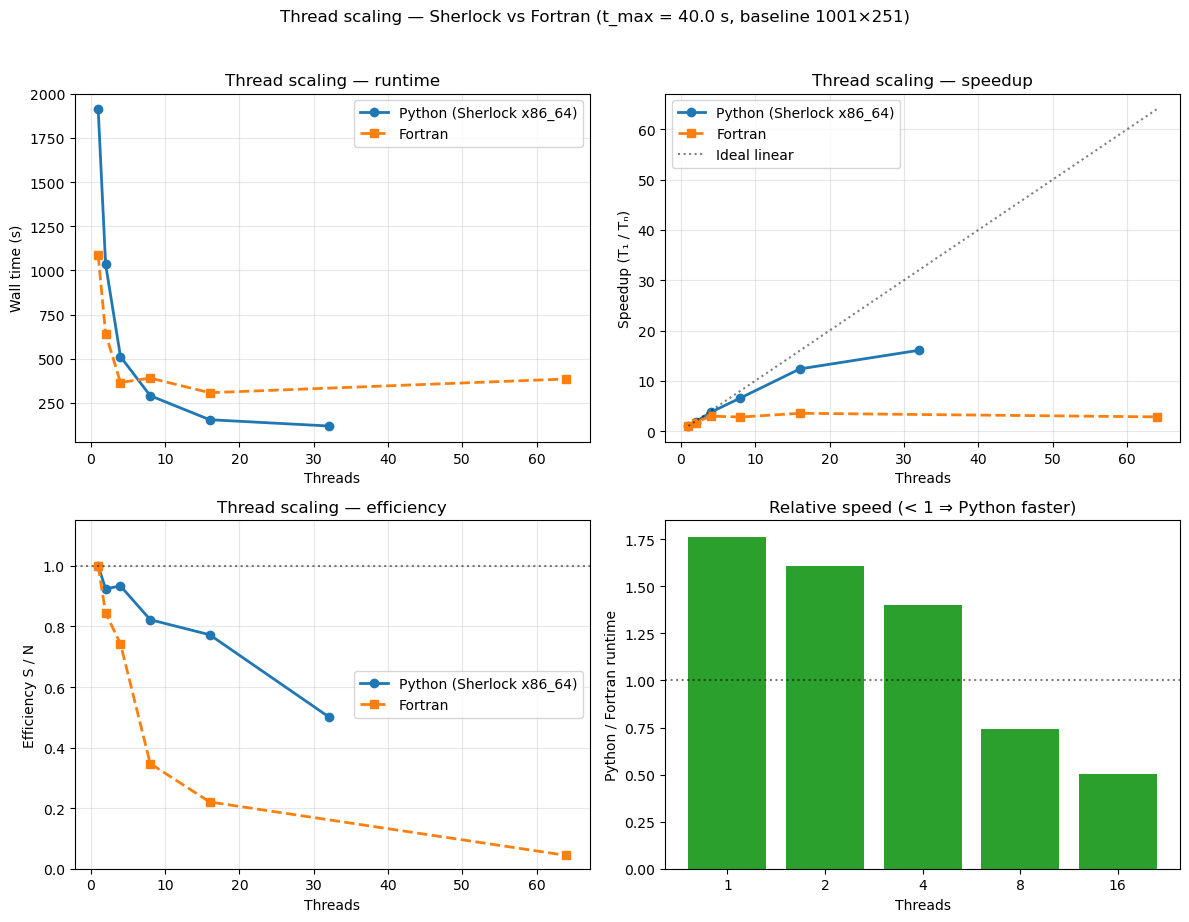

In [5]:
PY_LABEL = f"Python (Sherlock {py_host})"

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ideal_threads = np.array([1, 2, 4, 8, 16, 32, 64])

# Runtime
ax = axes[0, 0]
ax.plot(py_thread_df["threads"], py_thread_df["time_seconds"], "o-", label=PY_LABEL, linewidth=2)
ax.plot([r.threads for r in ft_thread], [r.time_seconds for r in ft_thread], "s--", label="Fortran", linewidth=2)
ax.set_xlabel("Threads")
ax.set_ylabel("Wall time (s)")
ax.set_title("Thread scaling — runtime")
ax.legend()
ax.grid(True, alpha=0.3)

# Speedup
ax = axes[0, 1]
ax.plot(py_thread_metrics["scale"], py_thread_metrics["speedup"], "o-", label=PY_LABEL, linewidth=2)
ax.plot(ft_thread_metrics["scale"], ft_thread_metrics["speedup"], "s--", label="Fortran", linewidth=2)
ax.plot(ideal_threads, ideal_threads, "k:", alpha=0.5, label="Ideal linear")
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup (T₁ / Tₙ)")
ax.set_title("Thread scaling — speedup")
ax.legend()
ax.grid(True, alpha=0.3)

# Efficiency
ax = axes[1, 0]
ax.plot(py_thread_metrics["scale"], py_thread_metrics["efficiency"], "o-", label=PY_LABEL, linewidth=2)
ax.plot(ft_thread_metrics["scale"], ft_thread_metrics["efficiency"], "s--", label="Fortran", linewidth=2)
ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
ax.set_xlabel("Threads")
ax.set_ylabel("Efficiency S / N")
ax.set_ylim(0, 1.15)
ax.set_title("Thread scaling — efficiency")
ax.legend()
ax.grid(True, alpha=0.3)

# Speedup ratio Python / Fortran
ax = axes[1, 1]
merged = py_thread_df.merge(
    pd.DataFrame({"threads": [r.threads for r in ft_thread], "fortran_s": ft_thread_times}),
    on="threads",
    how="inner",
)
if not merged.empty:
    ax.bar(merged["threads"].astype(str), merged["time_seconds"] / merged["fortran_s"], color="C2")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Threads")
    ax.set_ylabel("Python / Fortran runtime")
    ax.set_title("Relative speed (< 1 ⇒ Python faster)")
else:
    ax.text(0.5, 0.5, "No overlapping thread counts", ha="center", va="center", transform=ax.transAxes)

fig.suptitle(f"Thread scaling — Sherlock vs Fortran (t_max = {TMAX} s, baseline 1001×251)", y=1.02)
fig.tight_layout()
fig.savefig(EXAMPLE_DIR / "python_vs_fortran_thread_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

## Spatial scaling — Python (Sherlock) vs Fortran

Grids follow the Fortran `test1_sN` pattern (total grid points ≈ N × baseline).
Reference slope: runtime ∝ grid-point count (same nt).

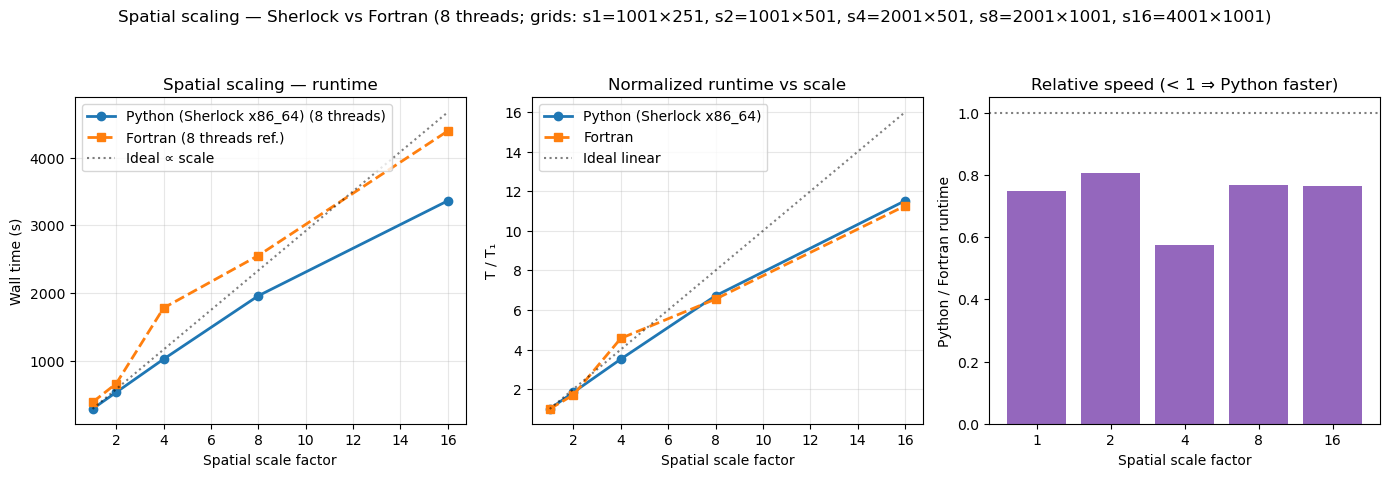

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

scale_py = py_spatial_df["spatial_factor"].to_numpy(dtype=float)
scale_ft = ft_spatial_df["spatial_factor"].to_numpy(dtype=float)
s1_py = py_spatial_df["time_seconds"].iloc[0]
s1_ft = ft_spatial_df["time_seconds"].iloc[0]

ax = axes[0]
ax.plot(scale_py, py_spatial_df["time_seconds"], "o-", label=f"{PY_LABEL} (8 threads)", linewidth=2)
ax.plot(scale_ft, ft_spatial_df["time_seconds"], "s--", label="Fortran (8 threads ref.)", linewidth=2)
ideal = scale_py * s1_py
ax.plot(scale_py, ideal, "k:", alpha=0.5, label="Ideal ∝ scale")
ax.set_xlabel("Spatial scale factor")
ax.set_ylabel("Wall time (s)")
ax.set_title("Spatial scaling — runtime")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(scale_py, py_spatial_df["time_seconds"] / s1_py, "o-", label=PY_LABEL, linewidth=2)
ax.plot(scale_ft, ft_spatial_df["time_seconds"] / s1_ft, "s--", label="Fortran", linewidth=2)
ax.plot(scale_py, scale_py, "k:", alpha=0.5, label="Ideal linear")
ax.set_xlabel("Spatial scale factor")
ax.set_ylabel("T / T₁")
ax.set_title("Normalized runtime vs scale")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
cmp = py_spatial_df.merge(ft_spatial_df, on="spatial_factor", suffixes=("_py", "_ft"))
if not cmp.empty:
    ax.bar(cmp["spatial_factor"].astype(str), cmp["time_seconds_py"] / cmp["time_seconds_ft"], color="C4")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Spatial scale factor")
    ax.set_ylabel("Python / Fortran runtime")
    ax.set_title("Relative speed (< 1 ⇒ Python faster)")
else:
    ax.text(0.5, 0.5, "No overlapping scales", ha="center", va="center", transform=ax.transAxes)

fig.suptitle(
    "Spatial scaling — Sherlock vs Fortran (8 threads; grids: "
    + ", ".join(f"s{k}={v[0]}×{v[1]}" for k, v in SPATIAL_GRIDS.items())
    + ")",
    y=1.05,
)
fig.tight_layout()
fig.savefig(EXAMPLE_DIR / "python_vs_fortran_spatial_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

**11 Sherlock jobs completed** (6 thread + 5 spatial) at full t_max = 40 s, merged from
`sherlock/results/*.json` (host: x86_64, SERC partition).

**Thread scaling (baseline 1001×251):**
- Python (Sherlock): 1911 s (1 thread) → 119 s (32 threads), **16.1× speedup**, best efficiency ~50% at 32 threads.
- Fortran: 1085 s → 308 s (16 threads), **3.5× speedup**; both codes show non-monotonic scaling around 7–9 threads (Fortran).
- Python is **~1.8× slower at 1 thread** but becomes **~0.5–0.7× (faster) at 8–16 threads** vs Fortran on overlapping counts.

**Spatial scaling (8 threads):**
- Python tracks grid-point count roughly linearly (T/T₁ ≈ 1.0, 1.8, 3.5, 6.7, 11.5 for scales 1–16).
- Python is **~0.58–0.81× Fortran runtime** at every scale (25–42% faster on Sherlock x86).

**Caveats:** laterally homogeneous 1-D FK model (no resampled vp/vs SU grids); 401 receivers vs Fortran's 1001. Hardware differs from original Fortran cluster runs (Sherlock x86 vs historical Fortran node).